# 第三部分 3.2：卷积神经网络（CNN）

| 章节 | 内容 |
|------|------|
| **3.4 卷积神经网络** | 卷积层、池化层、经典架构（LeNet → VGG → ResNet）|

---

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

matplotlib.rcParams['font.family'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('环境就绪，PyTorch 版本：', torch.__version__)
print('使用设备：', device)

## 3.4 卷积神经网络（CNN）

### 为什么不直接用 MLP 处理图像？

一张 32×32 RGB 图像有 `32 × 32 × 3 = 3072` 个像素。如果用全连接层，输入层就有 3072 个神经元，第一个隐藏层假设有 1000 个神经元，光这一层就有 **300 万个参数**（3072 × 1000 = 3,072,000）。对于 224×224 的图像，参数量爆炸式增长。

更根本的问题：**MLP 把图像展平成一维向量，丢失了空间结构**。「猫的左耳和右耳相邻」这类空间关系，展平后就消失了。

---

### 卷积层的核心思想

CNN 的解决方案基于两个关键假设：

1. **局部性（Locality）**：图像中的特征（边缘、纹理、角点）只依赖局部区域，不需要看整张图
2. **平移不变性（Translation Invariance）**：同样的特征在图像的任何位置都应被识别（左上角的猫耳和右下角的猫耳，用同一套参数检测）

**卷积操作**：用一个小的**卷积核（Kernel / Filter）** 在整张图上滑动，每次只看一个局部区域（感受野），输出该区域的特征响应。

```
输入图像（H × W）+ 卷积核（k × k）→ 特征图（Feature Map）

每个输出位置 = 卷积核 与 对应局部区域 的 点积 + 偏置
```

**参数共享**：同一个卷积核在整张图上都用相同的权重。一个 3×3 卷积核只有 9 个参数，却能处理整张图——这是 CNN 参数效率极高的根本原因。

---

### 关键超参数

| 超参数 | 含义 | 典型值 |
|--------|------|--------|
| **kernel_size** | 卷积核大小 | 3×3（最常用）、5×5、1×1 |
| **stride** | 卷积核每次移动的步长 | 1（默认）、2（下采样，替代池化）|
| **padding** | 在图像边缘填充 0 的圈数 | 1（保持特征图大小不变，当 kernel=3 时）|
| **out_channels** | 卷积核数量（学习多少种特征）| 16/32/64/128 |

输出特征图大小公式（以单边为例）：
$$H_{out} = \left\lfloor \frac{H_{in} + 2 \times \text{padding} - \text{kernel\_size}}{\text{stride}} \right\rfloor + 1$$

---

### 池化层（Pooling）

池化层减少特征图的空间尺寸（宽高），同时保留最重要的特征。

- **Max Pooling**：取局部区域的最大值。最常用，保留最强的激活信号
- **Average Pooling**：取局部区域的平均值。用于网络末端（全局平均池化）

**MaxPool 2×2 的计算过程**：把特征图划分成不重叠的 2×2 格子，每个格子只保留最大值，空间尺寸减半：

```
原始特征图（4×4）              MaxPool 后（2×2）

  1  3 | 2  1              左上 {1,3,0,4} → 4    右上 {2,1,1,2} → 2
  0  4 | 1  2      →                                                →   4  2
 ------+------              左下 {2,1,0,2} → 2    右下 {5,3,3,4} → 5       2  5
  2  1 | 5  3
  0  2 | 3  4
```

**池化会丢失信息，为什么是好事？**

池化丢掉的是"特征精确在哪个像素"，保留的是"这个区域有没有这个特征"。以检测猫耳朵为例：卷积核在某个 2×2 区域里扫到了强响应，这个响应在格子内的具体位置（左上还是右下）其实不重要，重要的是**这个区域有猫耳朵**。MaxPool 取最大值，正好保留了"有没有"，丢掉了"精确在哪"。

这也是 CNN 能做到**平移不变性**的原因之一——猫耳朵往左挪了一两个像素，经过池化后结果几乎不变，模型不会因为位置的微小偏移就认不出来。

另一个好处是**减少计算量**：特征图从 32×32 变成 16×16，数据量缩小到 1/4，这让后续卷积层可以用更多通道（16 → 32 → 64）在不爆显存的前提下检测更多种类的特征。

**池化 vs 下采样**

两者不完全等价。"下采样"是目的——减小空间尺寸；池化是实现下采样的一种手段，但不是唯一的。现代网络（如 ResNet）也常用 `stride=2` 的卷积层代替池化来做下采样，参数可学习，效果相近。所以说"池化层做下采样"是对的，反过来说"下采样就是池化"则不一定。

**全局平均池化（Global Average Pooling, GAP）**：直接对整个特征图取平均，将 `C × H × W` 的特征图压缩为 `C` 维向量。相比全连接层参数更少，是现代网络（ResNet 之后）的标准做法。

---

### 经典架构演进

CNN 架构经历了从手工设计到自动搜索的演进历程，每一代架构都解决了上一代的核心瓶颈：

| 架构 | 年份 | 创新点 | 核心局限 |
|------|------|--------|----------|
| **LeNet-5** | 1998 | 卷积 + 池化 + 全连接，首次成功应用 | 网络太浅，只能处理简单任务 |
| **AlexNet** | 2012 | 深层网络 + ReLU + Dropout + GPU 训练，ImageNet 冠军 | 全连接层参数量巨大（6000万参数）|
| **VGG** | 2014 | 全部用 3×3 小卷积核堆叠，结构简洁规律 | 深度受限：深层网络退化问题，梯度难以传播 |
| **ResNet** | 2015 | **残差连接（Skip Connection）**，训练 152 层网络 | - |

---

### ResNet：残差连接

深层网络面临的核心问题：随着深度增加，训练 Loss 反而比浅层网络更高（不是过拟合，而是**退化问题**）——梯度在反向传播中多次相乘后消失，深层权重几乎得不到更新。

ResNet 的解决方案：在每两层之间加一条**捷径（Shortcut / Skip Connection）**，直接把输入加到输出上：

$$\mathbf{y} = F(\mathbf{x}) + \mathbf{x}$$

其中 $F(\mathbf{x})$ 是两层卷积的输出，$\mathbf{x}$ 是跳过这两层直接传来的输入。

**为什么有效？**

1. **梯度高速公路**：反向传播时，梯度可以沿着 $\mathbf{x}$ 这条直接通路无损传回去，不依赖乘以很多次小数
2. **恒等学习**：最坏情况下，如果 $F(\mathbf{x}) = 0$，该层等价于什么都不做（恒等映射）。网络不会因为层数多而退化
3. **学习残差**：$F(\mathbf{x})$ 只需要学习输出和输入之间的**差值（残差）**，比直接学习完整映射更容易

> 一个形象的类比：你要从 A 走到 B，正常路需要翻很多山（深层网络）。残差连接给你修了一条高速公路，大部分信号走高速，卷积层只负责微调——即使高速公路堵了，信号也能走山路慢慢传，不会完全中断。

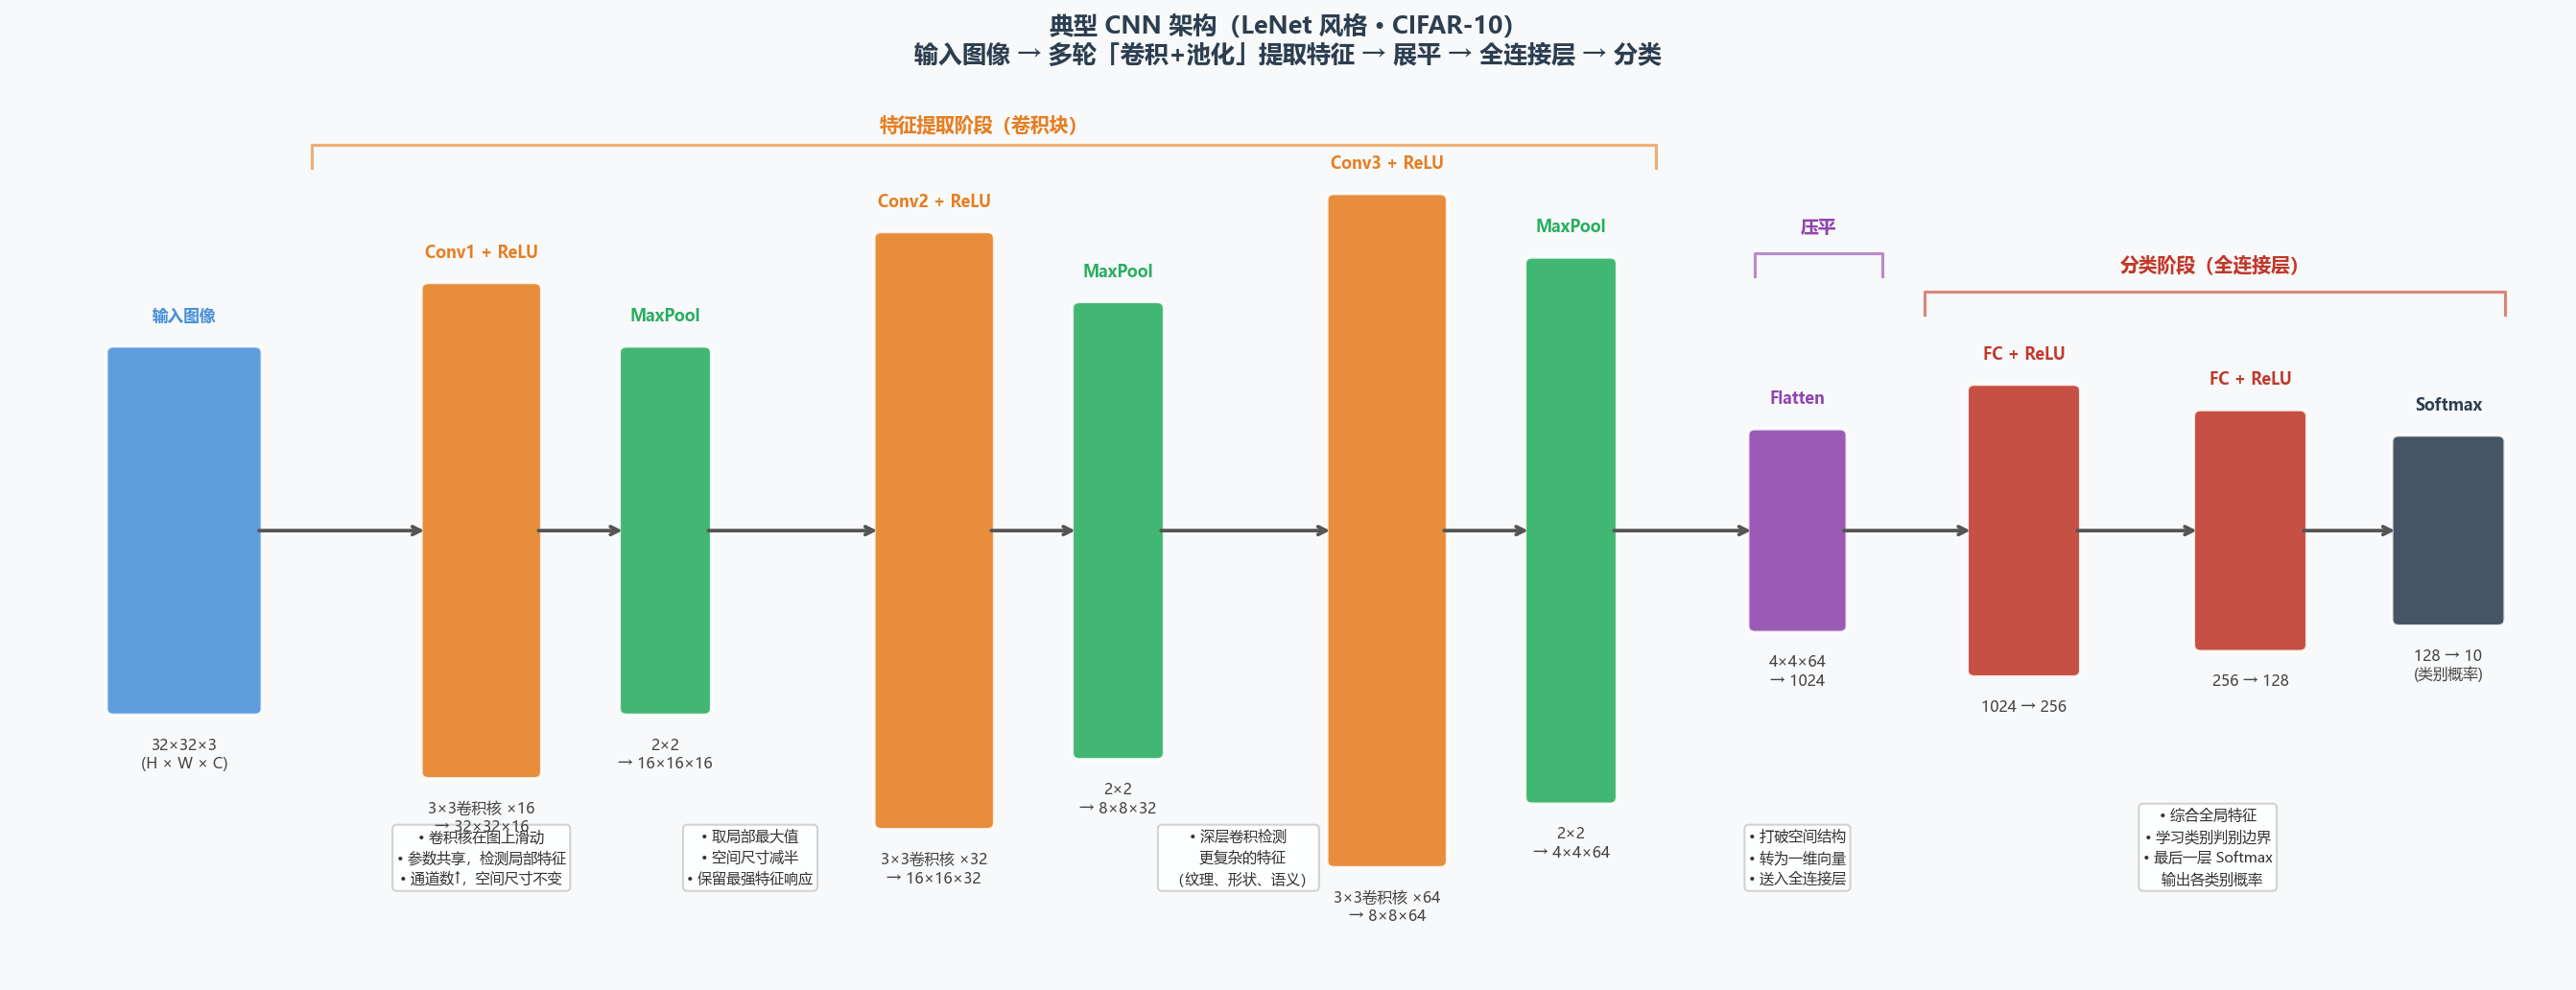

### 卷积核从哪里来？

#### 经典计算机视觉时代：手工设计

Sobel、高斯模糊、锐化……这些都是人类花了几十年总结出来的"有用卷积核"。它们确实管用，但有一个根本限制：**人类只能设计自己能理解的特征**。边缘、纹理可以描述，但"这张图里有猫"这种高层语义，没法用几个手工 kernel 表达出来。

#### CNN 的思路：让数据告诉你什么 kernel 有用

CNN 一开始把所有 kernel 的值初始化为随机小数。训练时，每次预测错了，就通过反向传播计算"把哪个 kernel 的哪个权重往哪个方向调一点点，损失会减小"，然后用梯度下降更新。重复几万次之后，kernel 自然收敛到对当前任务最有用的形态。

**有趣的地方在于：学出来的 kernel 和手工设计的很像。** 对训练好的 CNN 第一层卷积核可视化，会发现它们自发地学出了 Sobel 类似的边缘检测器、颜色对比检测器——这说明"边缘对识别图像有用"这件事，网络自己从数据里发现了。

但越往深走，kernel 检测的东西越抽象：

```
第 1 层 kernel：边缘、颜色梯度         ← 人类能理解
第 2 层 kernel：纹理、角点             ← 勉强能理解
第 3 层 kernel：眼睛形状、毛发走向     ← 说不太清楚
第 5 层 kernel："猫脸的某个组合特征"  ← 人类完全无法设计
```

深层 kernel 检测的特征没有人类语言能准确描述，但它们对分类任务极其有效——这正是手工设计无法企及的地方。

| | 手工 kernel（Sobel 等） | CNN 学到的 kernel |
|---|---|---|
| 怎么来的 | 人类经验设计 | 从数据里自动学 |
| 浅层效果 | 与学到的相近（都是边缘检测等） | 自动发现，无需人工 |
| 深层能力 | 无法设计 | 自动学出抽象特征 |
| 适用范围 | 通用，任务无关 | 针对具体任务优化 |

> Sobel 这类核是"人类智慧的上限"，CNN 的学习过程是"用数据突破这个上限"。

下面的演示用手工设计的经典卷积核来帮助理解卷积的工作原理——在真实 CNN 中，这些 kernel 的值是通过训练自动学出来的，不需要人工指定。

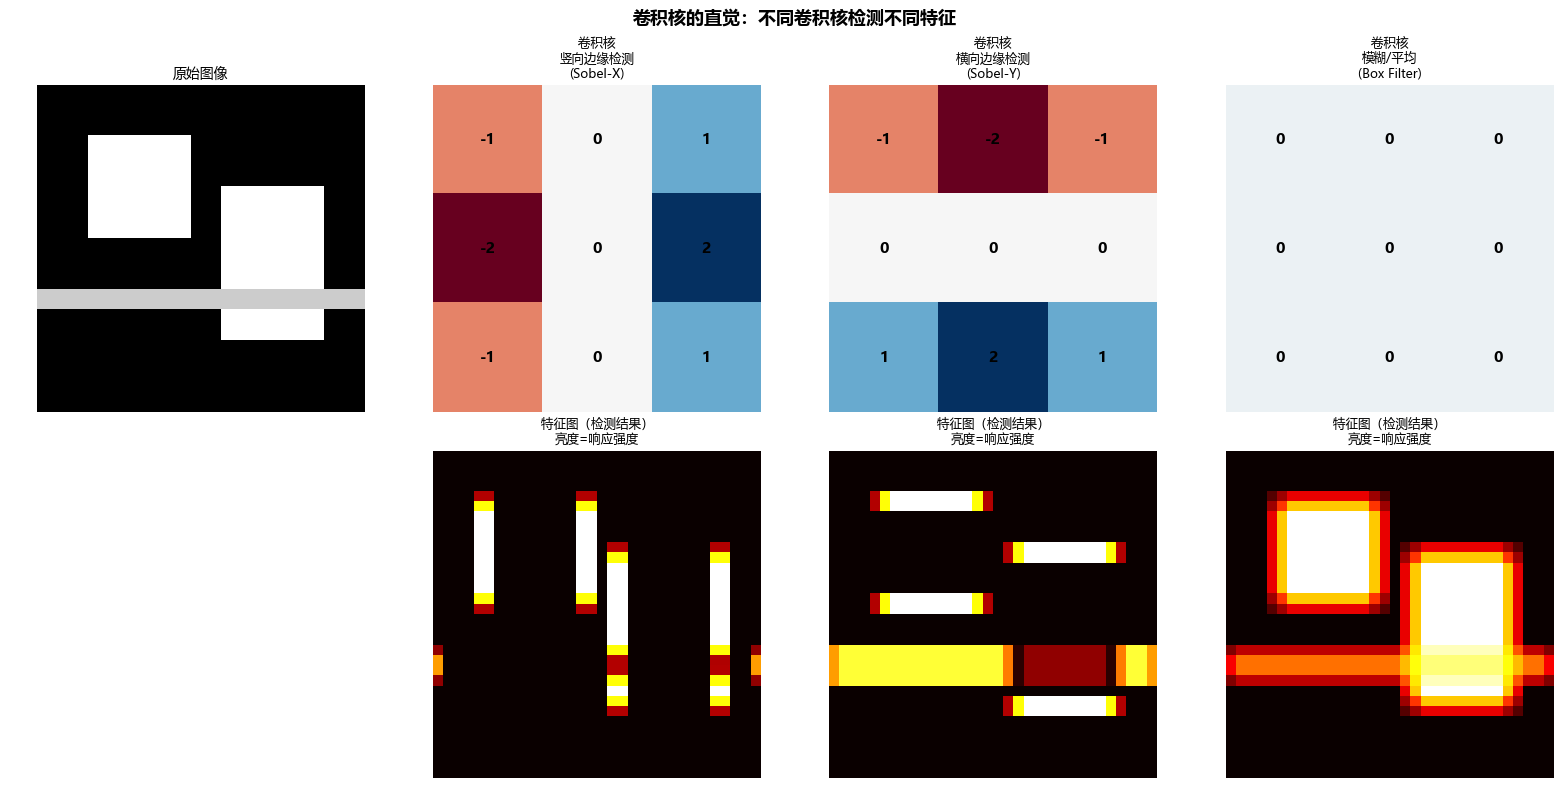

观察：
  Sobel-X（竖向边缘）：对垂直方向的颜色变化强烈响应 → 检测竖边
  Sobel-Y（横向边缘）：对水平方向的颜色变化强烈响应 → 检测横边
  Box Filter（模糊）  ：对局部均值响应 → 平滑图像
  CNN 训练时会自动学习出这些有用的卷积核，无需手工设计


In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ── 演示 1：卷积核的直觉 ────────────────────────────────────────
# 手工设计几个经典卷积核，展示它们分别能检测什么特征

# 用于演示的合成图像：黑白棋盘 + 几何形状
img_size = 32
img = np.zeros((img_size, img_size), dtype=np.float32)
img[5:15, 5:15] = 1.0      # 白色方块（左上）
img[10:25, 18:28] = 1.0    # 白色方块（右中），两块有垂直边缘相交
# 加一条水平条纹
img[20:22, :] = 0.8

# 三种经典卷积核
kernels = {
    '竖向边缘检测\n(Sobel-X)': np.array([[-1, 0, 1],
                                          [-2, 0, 2],
                                          [-1, 0, 1]], dtype=np.float32),
    '横向边缘检测\n(Sobel-Y)': np.array([[-1, -2, -1],
                                          [ 0,  0,  0],
                                          [ 1,  2,  1]], dtype=np.float32),
    '模糊/平均\n(Box Filter)': np.ones((3, 3), dtype=np.float32) / 9,
}

# 用 PyTorch 的 F.conv2d 做卷积（等价于 nn.Conv2d 但可以手动指定权重）
import torch.nn.functional as F

# ── PyTorch 张量维度说明 ────────────────────────────────────────
# F.conv2d 要求输入是 4D 张量，格式为 (N, C, H, W)：
#   N = batch size（一次处理多少张图，这里只有 1 张）
#   C = channels（通道数，灰度图是 1，RGB 是 3）
#   H = height（图像高度）
#   W = width（图像宽度）
#
# img 现在是 numpy 数组，shape = (32, 32)，即 (H, W)
# 需要两次 unsqueeze 在最前面各加一个维度：
#   unsqueeze(0)：(32, 32) → (1, 32, 32)    加上 batch 维度 N
#   unsqueeze(0)：(1, 32, 32) → (1, 1, 32, 32)  再加上 channel 维度 C
img_t = torch.FloatTensor(img).unsqueeze(0).unsqueeze(0)  # shape: (1, 1, 32, 32)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('卷积核的直觉：不同卷积核检测不同特征', fontsize=13, fontweight='bold')

axes[0][0].imshow(img, cmap='gray', vmin=0, vmax=1)
axes[0][0].set_title('原始图像', fontsize=10)
axes[0][0].axis('off')
axes[1][0].axis('off')  # 占位

for i, (name, kernel) in enumerate(kernels.items(), 1):
    # kernel 是 numpy 数组，shape = (3, 3)，即 (kH, kW)
    # F.conv2d 要求卷积核也是 4D 张量，格式为 (out_channels, in_channels, kH, kW)：
    #   out_channels = 1（输出 1 张特征图，因为只有 1 个卷积核）
    #   in_channels  = 1（输入是单通道灰度图）
    #   kH, kW       = 3, 3（卷积核的高和宽）
    # 同样需要两次 unsqueeze(0)：(3,3) → (1,3,3) → (1,1,3,3)
    k_t = torch.FloatTensor(kernel).unsqueeze(0).unsqueeze(0)  # shape: (1, 1, 3, 3)

    # F.conv2d(input, weight, padding=1)
    #   input   : 待卷积的图像张量，shape (1, 1, 32, 32)
    #   weight  : 卷积核张量，     shape (1, 1, 3, 3)
    #   padding : 在图像四周填充 1 圈 0，使输出特征图与输入同等大小（32×32 → 32×32）
    #             不加 padding 时，3×3 卷积会让输出缩小：32 → 30
    # 输出 shape: (1, 1, 32, 32)，即 (N, out_channels, H, W)
    out_t = F.conv2d(img_t, k_t, padding=1)

    # squeeze() 去掉所有大小为 1 的维度：(1, 1, 32, 32) → (32, 32)
    # .numpy() 把 PyTorch 张量转回 numpy 数组，方便 matplotlib 显示
    out = out_t.squeeze().numpy()

    # 上：显示卷积核本身（3×3）
    axes[0][i].imshow(kernel, cmap='RdBu', vmin=-2, vmax=2)
    for r in range(3):
        for c in range(3):
            axes[0][i].text(c, r, f'{kernel[r, c]:.0f}',
                            ha='center', va='center', fontsize=11, fontweight='bold')
    axes[0][i].set_title(f'卷积核\n{name}', fontsize=9)
    axes[0][i].axis('off')

    # 下：显示卷积后的特征图
    # np.abs(out)：边缘检测卷积核的输出可以是负值（像素从亮→暗），取绝对值后
    # 正负边缘都显示为亮色，更直观地看出"哪里有边缘"
    axes[1][i].imshow(np.abs(out), cmap='hot')
    axes[1][i].set_title(f'特征图（检测结果）\n亮度=响应强度', fontsize=9)
    axes[1][i].axis('off')

plt.tight_layout()
plt.show()

print("观察：")
print("  Sobel-X（竖向边缘）：对垂直方向的颜色变化强烈响应 → 检测竖边")
print("  Sobel-Y（横向边缘）：对水平方向的颜色变化强烈响应 → 检测横边")
print("  Box Filter（模糊）  ：对局部均值响应 → 平滑图像")
print("  CNN 训练时会自动学习出这些有用的卷积核，无需手工设计")

In [ ]:
import torch
import torch.nn as nn

# ── 演示 2：参数量对比 MLP vs CNN ───────────────────────────────
print("=" * 60)
print("  参数量对比：MLP vs CNN（处理 32×32 灰度图像）")
print("=" * 60)

# MLP 方案：展平后全连接
class MLP_for_Image(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*32, 256),   # 32*32=1024 → 256
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )
    def forward(self, x): return self.net(x)

# CNN 方案：LeNet 风格
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 卷积块
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # (1,32,32)→(16,32,32)
            nn.ReLU(),
            nn.MaxPool2d(2),                             # →(16,16,16)
            nn.Conv2d(16, 32, kernel_size=3, padding=1), # →(32,16,16)
            nn.ReLU(),
            nn.MaxPool2d(2),                             # →(32,8,8)
        )
        # 分类头
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )
    def forward(self, x): return self.head(self.conv(x))

mlp = MLP_for_Image()
cnn = SimpleCNN()

def count_params(model):
    return sum(p.numel() for p in model.parameters())

print(f"\nMLP 总参数量：{count_params(mlp):,}")
print(f"CNN 总参数量：{count_params(cnn):,}")

print("\nMLP 各层参数：")
for name, param in mlp.named_parameters():
    print(f"  {name:<25} shape={str(list(param.shape)):<20} params={param.numel():,}")

print("\nCNN 各层参数：")
for name, param in cnn.named_parameters():
    print(f"  {name:<30} shape={str(list(param.shape)):<20} params={param.numel():,}")

print(f"\n参数效率比：MLP / CNN = {count_params(mlp) / count_params(cnn):.1f}x")
print("  → CNN 靠参数共享大幅减少参数量，同时保留了图像的空间结构")

# 验证特征图尺寸变化
print("\n=" * 60)
print("  CNN 特征图尺寸变化追踪")
print("=" * 60)
x = torch.zeros(1, 1, 32, 32)
print(f"  输入：{tuple(x.shape)}")
for i, layer in enumerate(cnn.conv):
    x = layer(x)
    print(f"  第{i+1}层 {type(layer).__name__:<15} 输出：{tuple(x.shape)}")

In [ ]:
import torch
import torch.nn as nn

# ── 演示 3：残差块（Residual Block）──────────────────────────────

class ResidualBlock(nn.Module):
    """ResNet 的基本单元"""
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = x              # 保存输入（shortcut）
        out = self.block(x)       # 主路径：两层卷积
        out = out + residual      # 残差连接：输出 = F(x) + x
        return self.relu(out)     # 加完再激活

# 构建一个简化版 ResNet 用于 CIFAR-10
class SmallResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 初始特征提取
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        # 残差块堆叠（3 个阶段，每个阶段 2 个残差块）
        self.layer1 = nn.Sequential(ResidualBlock(32), ResidualBlock(32))
        self.down1  = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True)
        )  # 下采样
        self.layer2 = nn.Sequential(ResidualBlock(64), ResidualBlock(64))
        self.down2  = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True)
        )
        self.layer3 = nn.Sequential(ResidualBlock(128), ResidualBlock(128))
        # 全局平均池化 + 分类头
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # (B, 128, H, W) → (B, 128, 1, 1)
            nn.Flatten(),             # → (B, 128)
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.down1(x)
        x = self.layer2(x)
        x = self.down2(x)
        x = self.layer3(x)
        return self.head(x)

model = SmallResNet()
print("SmallResNet 结构：")
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\n总参数量：{total_params:,}")

# 验证 forward 通路
x_test = torch.randn(4, 3, 32, 32)   # batch=4, 3通道, 32×32
out = model(x_test)
print(f"输入形状：{tuple(x_test.shape)}")
print(f"输出形状：{tuple(out.shape)}  （4个样本，10个类别的 logit）")

# 对比有 vs 没有残差连接的梯度流
print("\n=== 梯度流对比：有无残差连接 ===")

class PlainBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels), nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)  # 没有 + residual

def make_deep_net(block_cls, n_blocks, channels=32):
    layers = [nn.Conv2d(3, channels, 3, padding=1, bias=False),
              nn.ReLU(inplace=True)]
    for _ in range(n_blocks):
        layers.append(block_cls(channels))
    layers += [nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(channels, 10)]
    return nn.Sequential(*layers)

import matplotlib.pyplot as plt
import matplotlib

n_blocks_list = [2, 4, 8, 16]
grad_norms_plain = []
grad_norms_res   = []

x_g = torch.randn(8, 3, 32, 32)
y_g = torch.randint(0, 10, (8,))

for n in n_blocks_list:
    for norm_list, block_cls in [(grad_norms_plain, PlainBlock), (grad_norms_res, ResidualBlock)]:
        torch.manual_seed(0)
        net = make_deep_net(block_cls, n)
        net.zero_grad()
        loss = nn.CrossEntropyLoss()(net(x_g), y_g)
        loss.backward()
        # 取最早的卷积层梯度范数（越小说明梯度消失越严重）
        first_conv_grad = net[0].weight.grad
        norm_list.append(first_conv_grad.norm().item())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_blocks_list, grad_norms_plain, 'o-', color='C1', lw=2, label='无残差（Plain）')
ax.plot(n_blocks_list, grad_norms_res,   's-', color='C0', lw=2, label='残差连接（ResNet）')
ax.set_xlabel('残差块数量（网络深度）')
ax.set_ylabel('第一个卷积层的梯度范数')
ax.set_title('残差连接 vs 无残差：梯度流随深度的变化\n梯度范数越大，说明深层梯度传播越顺畅', fontsize=10)
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print("\n观察：")
print("  无残差网络：随着深度增加，最早层的梯度范数急剧下降（梯度消失）")
print("  有残差连接：梯度范数保持相对稳定，深层也能得到有效的梯度信号")
print("  → 残差连接给梯度提供了一条高速公路，是训练超深网络的关键")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)

# ── CIFAR-10 实战训练 ───────────────────────────────────────────
print("=== CIFAR-10 图像分类：SmallResNet 训练 ===")
print("  数据集：CIFAR-10，60000 张 32×32 彩色图，10 个类别")
print("  类别：飞机/汽车/鸟/猫/鹿/狗/青蛙/马/船/卡车")
print()

# 数据预处理
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),           # 随机水平翻转（数据增强）
    transforms.RandomCrop(32, padding=4),         # 随机裁剪（数据增强）
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_train)
test_set  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False, num_workers=0)

# 可视化数据集样例
classes = ['飞机','汽车','鸟','猫','鹿','狗','青蛙','马','船','卡车']
imgs, lbls = next(iter(DataLoader(test_set, batch_size=20, shuffle=True)))

fig, axes = plt.subplots(2, 10, figsize=(14, 3))
fig.suptitle('CIFAR-10 样例图片', fontsize=11)
mean = np.array([0.4914, 0.4822, 0.4465])
std  = np.array([0.2023, 0.1994, 0.2010])
for i in range(20):
    ax = axes[i // 10][i % 10]
    img_show = imgs[i].numpy().transpose(1, 2, 0) * std + mean
    ax.imshow(np.clip(img_show, 0, 1))
    ax.set_title(classes[lbls[i].item()], fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()

# 训练
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = SmallResNet(num_classes=10).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
loss_fn   = nn.CrossEntropyLoss()

EPOCHS = 20
train_losses, test_accs = [], []

print(f"训练 {EPOCHS} 轮（设备：{device}）...")
for ep in range(EPOCHS):
    model.train()
    ep_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()
        ep_loss += loss.item()
    scheduler.step()

    # 测试
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total   += yb.size(0)
    acc = correct / total
    avg_loss = ep_loss / len(train_loader)
    train_losses.append(avg_loss)
    test_accs.append(acc)
    if (ep + 1) % 5 == 0 or ep == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"  Epoch {ep+1:2d}/{EPOCHS}  Loss={avg_loss:.3f}  测试准确率={acc:.3f}  LR={lr_now:.5f}")

# 训练曲线
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('CIFAR-10 训练结果（SmallResNet）', fontsize=12)
axes[0].plot(train_losses, 'o-', color='C0', lw=1.5)
axes[0].set_title('训练 Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[1].plot(test_accs,  's-', color='C1', lw=1.5)
axes[1].set_title(f'测试准确率（最终：{test_accs[-1]:.3f}）')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.4, 1.0)
plt.tight_layout()
plt.show()

print(f"\n最终测试准确率：{test_accs[-1]:.3f}")
print(f"CIFAR-10 随机猜测基准：0.100（10类均等）")
print(f"人类水平约 0.94，论文 SOTA 约 0.99")
print(f"→ 仅 {sum(p.numel() for p in model.parameters()):,} 参数、20 轮训练，准确率已超过随机基准 3~4 倍")